In [ ]:
# =========================================
# 1. Imports
# =========================================
from pathlib import Path
import argparse
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport
from scipy.stats import chi2_contingency

BASE_PATH = Path.cwd()
if not (BASE_PATH / "data" / "whodecide" / "processed" / "selects_2023_clean.csv").exists():
    BASE_PATH = BASE_PATH.parent


c:\Users\baber\Documents\PODSV-Projekt\PODSV_Visualisierungsprojekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================================
# 2. CSV-Dateien einlesen
# =========================================

PROCESSED_SELECTS_2023_PATH = BASE_PATH / "data" / "whodecide" / "processed" / "selects_2023_clean.csv"
PROCESSED_SELECTS_2019_PATH = BASE_PATH / "data" / "whodecide" / "processed" / "selects_2019_clean.csv"

df_2023 = pd.read_csv(PROCESSED_SELECTS_2023_PATH)
df_2019 = pd.read_csv(PROCESSED_SELECTS_2019_PATH)

df_2023["year"] = 2023
df_2019["year"] = 2019

print(df_2023.shape, df_2019.shape)

C:\Users\baber\AppData\Local\Temp\ipykernel_27368\4026414816.py:8: DtypeWarning: Columns (206,207,208,209,210,211,212,213,214,215) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv(PROCESSED_SELECTS_2023_PATH)


(5033, 309) (6664, 342)


In [3]:
# Spalten-Check: sind die relevanten Variablen in beiden Datensätzen vorhanden?
cols_needed = ["birthyear", "f11100rec", "f10100", "f11301", "f11302", "f11305"]

for col in cols_needed:
    in_2023 = col in df_2023.columns
    in_2019 = col in df_2019.columns
    print(f"{col}: 2023={'✓' if in_2023 else '✗'}  2019={'✓' if in_2019 else '✗'}")

birthyear: 2023=✓  2019=✓
f11100rec: 2023=✓  2019=✓
f10100: 2023=✓  2019=✓
f11301: 2023=✓  2019=✓
f11302: 2023=✓  2019=✓
f11305: 2023=✓  2019=✓


In [7]:
# =========================================
# 3. Daten vorbereiten
# =========================================

generation_order = [
    "Silent Generation",
    "Baby Boomers",
    "Generation X",
    "Millennials",
    "Generation Z"
]

def assign_generation(year):
    if pd.isna(year):
        return pd.NA
    elif year <= 1945:
        return "Silent Generation"
    elif 1946 <= year <= 1964:
        return "Baby Boomers"
    elif 1965 <= year <= 1980:
        return "Generation X"
    elif 1981 <= year <= 1996:
        return "Millennials"
    else:
        return "Generation Z"

def prepare_df(df):
    df = df.copy()
    df = df[df["f11100rec"] >= 0]
    df["generation"] = df["birthyear"].apply(assign_generation)
    df["voted"] = df["f11100rec"]
    df["political_interest"] = df["f10100"].replace([-99, -98], np.nan)
    trust_vars = ["f11301", "f11302", "f11305"]
    df[trust_vars] = df[trust_vars].apply(pd.to_numeric, errors="coerce")
    df[trust_vars] = df[trust_vars].replace([-99, -98], np.nan)
    df["trust_avg"] = df[trust_vars].mean(axis=1)
    return df

df_2023 = prepare_df(df_2023)
df_2019 = prepare_df(df_2019)

print("2023:", df_2023.shape, "| 2019:", df_2019.shape)

2023: (4984, 313) | 2019: (6610, 346)


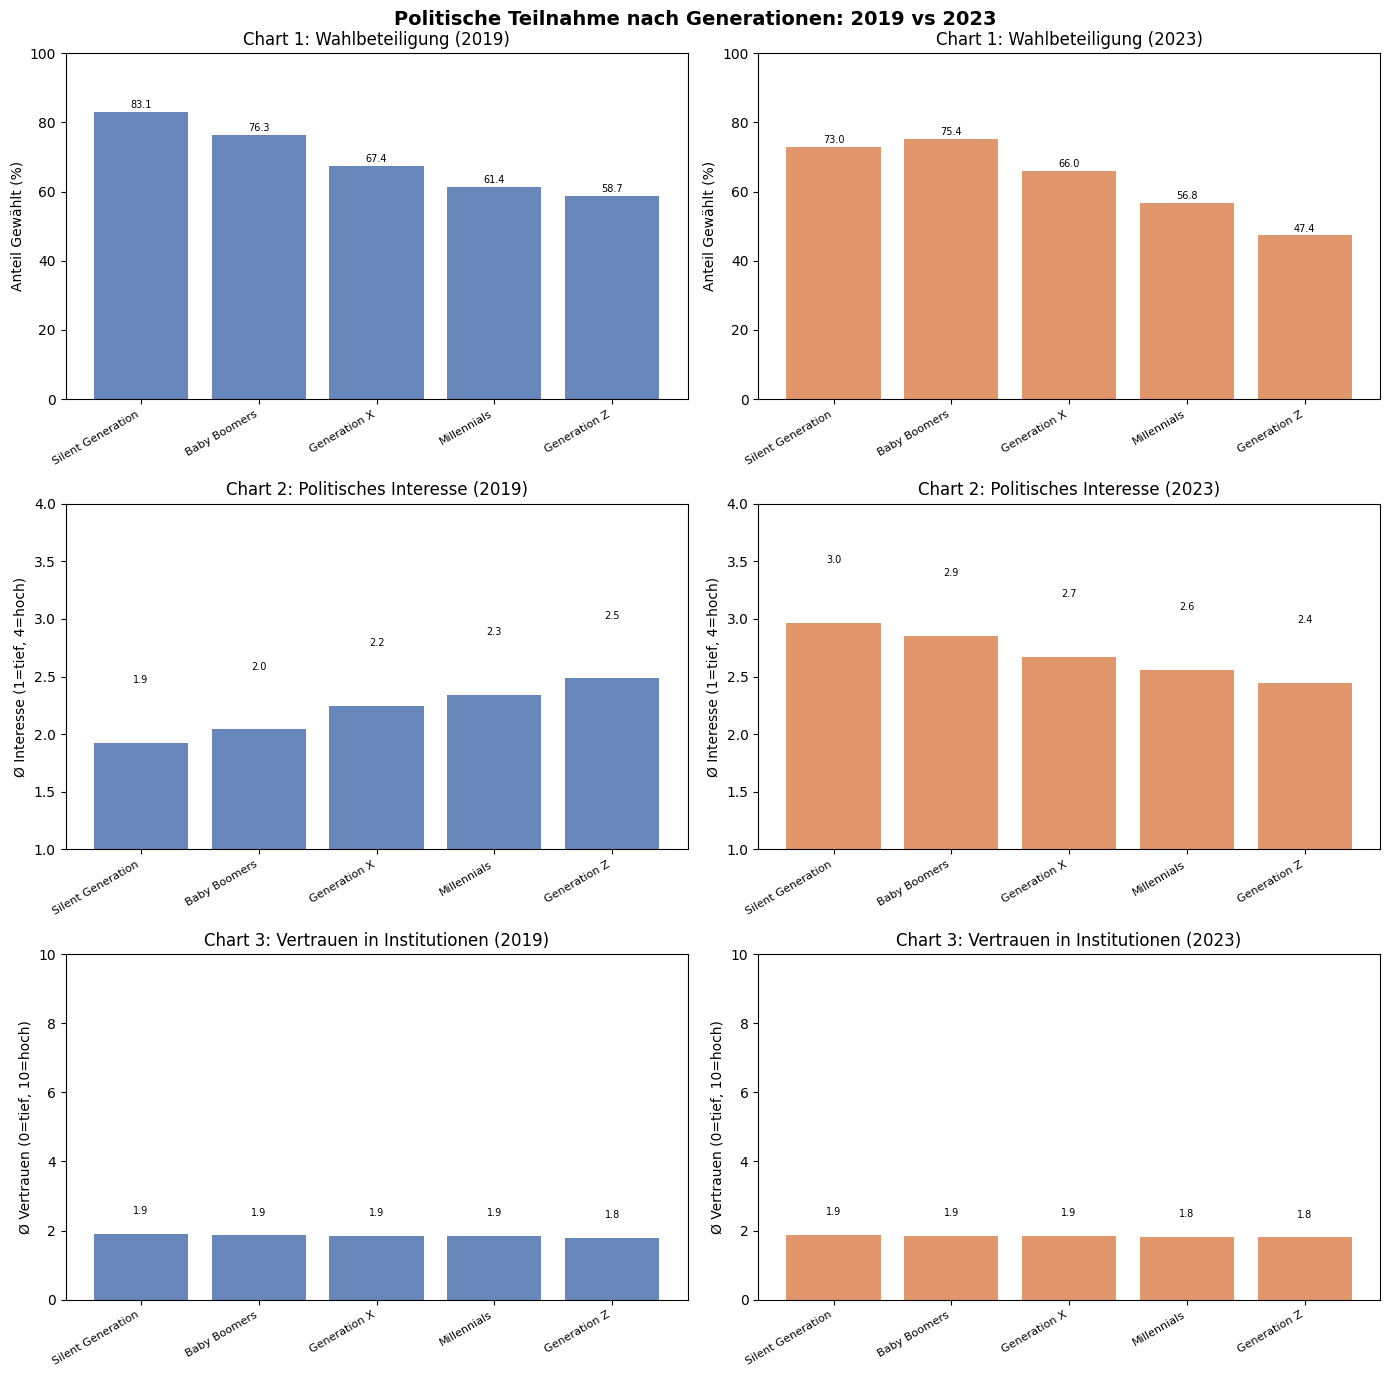

In [10]:
# =========================================
# 4. Charts: 2019 vs 2023 Vergleich
# =========================================

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle("Politische Teilnahme nach Generationen: 2019 vs 2023", fontsize=14, fontweight="bold")

datasets = {"2019": df_2019, "2023": df_2023}
colors   = {"2019": "#4C72B0", "2023": "#DD8452"}

metrics = [
    ("voted",             "Chart 1: Wahlbeteiligung",           "Anteil Gewählt (%)",            (0, 100), True),
    ("political_interest","Chart 2: Politisches Interesse",     "Ø Interesse (1=tief, 4=hoch)",  (1, 4),   False),
    ("trust_avg",         "Chart 3: Vertrauen in Institutionen","Ø Vertrauen (0=tief, 10=hoch)", (0, 10),  False),
]

for row, (metric, title, ylabel, ylim, pct) in enumerate(metrics):
    for col, (year, df) in enumerate(datasets.items()):
        ax = axes[row][col]

        values = (
            df.groupby("generation")[metric].mean().reindex(generation_order)
        )
        if pct:
            values = values * 100

        bars = ax.bar(generation_order, values, color=colors[year], alpha=0.85)
        ax.set_title(f"{title} ({year})")
        ax.set_ylabel(ylabel)
        ax.set_ylim(ylim)
        ax.set_xticks(range(len(generation_order)))
        ax.set_xticklabels(generation_order, rotation=30, ha="right", fontsize=8)

        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f"{val:.1f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

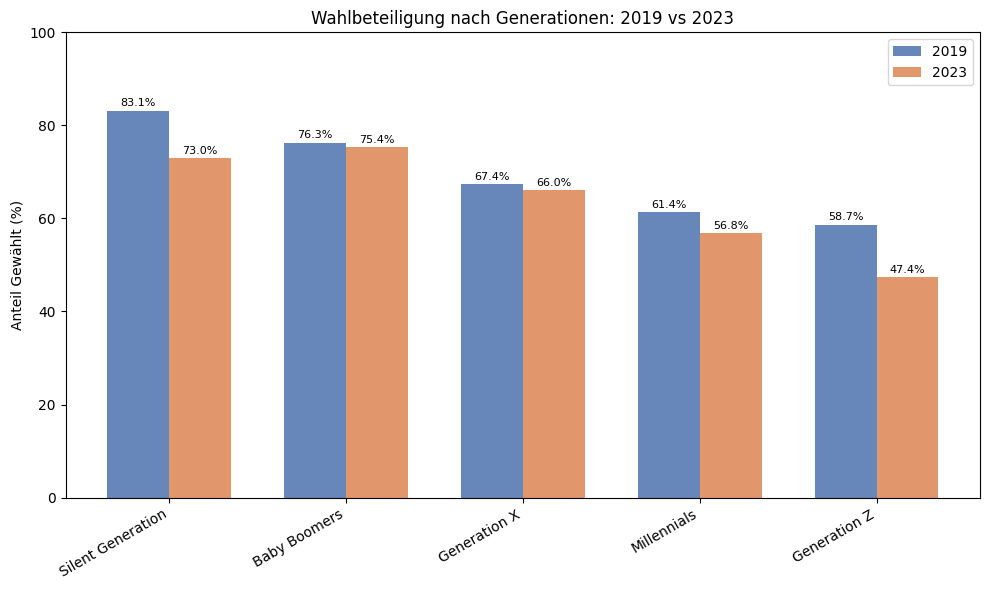

In [11]:
# =========================================
# Chart 1: Wahlbeteiligung 2019 vs 2023
# =========================================

turnout_2019 = df_2019.groupby("generation")["voted"].mean().reindex(generation_order) * 100
turnout_2023 = df_2023.groupby("generation")["voted"].mean().reindex(generation_order) * 100

x = np.arange(len(generation_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_2019 = ax.bar(x - width/2, turnout_2019, width, label="2019", color="#4C72B0", alpha=0.85)
bars_2023 = ax.bar(x + width/2, turnout_2023, width, label="2023", color="#DD8452", alpha=0.85)

for bar, val in zip(bars_2019, turnout_2019):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

for bar, val in zip(bars_2023, turnout_2023):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

ax.set_title("Wahlbeteiligung nach Generationen: 2019 vs 2023")
ax.set_ylabel("Anteil Gewählt (%)")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(generation_order, rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# Chart 1: Statistischer Test — Chi²
# =========================================


for gen in generation_order:
    group_2019 = df_2019[df_2019["generation"] == gen]["voted"].reset_index(drop=True)
    group_2023 = df_2023[df_2023["generation"] == gen]["voted"].reset_index(drop=True)

    contingency = pd.crosstab(
        pd.concat([group_2019, group_2023]).reset_index(drop=True),
        pd.concat([pd.Series(["2019"] * len(group_2019)),
                   pd.Series(["2023"] * len(group_2023))]).reset_index(drop=True)
    )

    chi2, p, dof, _ = chi2_contingency(contingency)
    sig = "✓ signifikant" if p < 0.05 else "✗ nicht signifikant"
    print(f"{gen:<20} chi2={chi2:.2f}  p={p:.3f}  {sig}")

Silent Generation    chi2=14.82  p=0.000  ✓ signifikant
Baby Boomers         chi2=0.42  p=0.516  ✗ nicht signifikant
Generation X         chi2=0.66  p=0.418  ✗ nicht signifikant
Millennials          chi2=5.19  p=0.023  ✓ signifikant
Generation Z         chi2=11.05  p=0.001  ✓ signifikant


In [16]:
###
# Chart 2: Politisches Interesse über Generationen hinweg
###
# Daten vorbereiten

df["political_interest"] = df["f10100"].replace([-99, -98], np.nan)

In [17]:
###
# politisches Interesse über Generationen hinweg
# ausführen
###
interest_by_generation = (
    df.groupby("generation")["political_interest"]
      .mean()
      .reindex(generation_order)
)

interest_by_generation

generation
Silent Generation    2.968170
Baby Boomers         2.854024
Generation X         2.673035
Millennials          2.559856
Generation Z         2.443160
Name: political_interest, dtype: float64

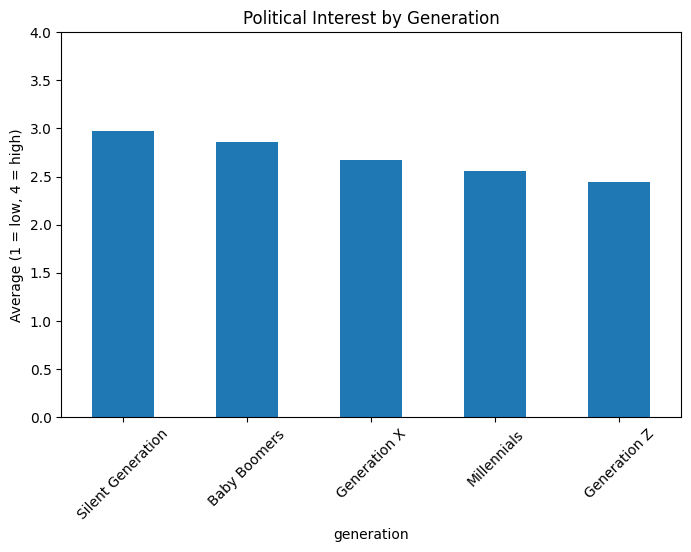

In [18]:
###
# politisches Interesse über Generationen hinweg
# visualisieren
###
plt.figure(figsize=(8, 5))
interest_by_generation.plot(kind="bar")

plt.title("Political Interest by Generation")
plt.ylabel("Average (1 = low, 4 = high)")
plt.xticks(rotation=45)
plt.ylim(0, 4)

plt.show()

In [19]:
###
# Anova: Politisches Interesse über Generationen hinweg
# Daten vorbereiten
###
groups = [
    group["political_interest"].dropna()
    for name, group in df.groupby("generation")
]

In [20]:
###
# Anova-test durchführen
###
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 48.014174531429504
p-value: 1.1278489959358468e-39


In [21]:
###
# Tukey-HSD-Test:
# Nachdem die ANOVA gezeigt hat, dass sich das politische Interesse zwischen den Generationen insgesamt unterscheidet,
# wird dieser Test verwendet, um zu bestimmen, zwischen welchen konkreten Generationen signifikante Unterschiede bestehen.
# Dabei wird berücksichtigt, dass mehrere Gruppenvergleiche gleichzeitig durchgeführt werden.
###
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_tukey = df[["generation", "political_interest"]].dropna()

tukey = pairwise_tukeyhsd(
    endog=df_tukey["political_interest"],
    groups=df_tukey["generation"],
    alpha=0.05
)

print(tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1          group2      meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
Baby Boomers      Generation X   -0.181    0.0 -0.2612 -0.1008   True
Baby Boomers      Generation Z  -0.4109    0.0 -0.5207  -0.301   True
Baby Boomers       Millennials  -0.2942    0.0 -0.3791 -0.2092   True
Baby Boomers Silent Generation   0.1141 0.0905 -0.0104  0.2387  False
Generation X      Generation Z  -0.2299    0.0 -0.3421 -0.1176   True
Generation X       Millennials  -0.1132 0.0041 -0.2011 -0.0252   True
Generation X Silent Generation   0.2951    0.0  0.1685  0.4218   True
Generation Z       Millennials   0.1167 0.0468   0.001  0.2324   True
Generation Z Silent Generation    0.525    0.0  0.3778  0.6722   True
 Millennials Silent Generation   0.4083    0.0  0.2786   0.538   True
---------------------------------------------------------------------


In [22]:
###
# Chart 3 Vertrauen in Institutionen über Generationen hinweg
###
# Daten vorbereiten
trust_vars = [
    "f11301",  # Parliament
    "f11302",  # Government
    "f11305",  # Parties
]

df[trust_vars] = df[trust_vars].replace([-99, -98], np.nan)

Stehen geblieben bei Chart 3..

# Who decides? — Fahrplan ( notiz für mich)

## Ziel
Untersuchen, wie sich politische Teilnahme zwischen Generationen unterscheidet
und welche Faktoren diese Unterschiede erklären.

---

## 1. Wahlbeteiligung (Turnout)

- Ältere Generationen wählen deutlich häufiger
- Jüngere Generationen beteiligen sich weniger

👉 Zentrale Beobachtung:
Es gibt einen klaren Unterschied in politischer Teilnahme

---

## 2. Politisches Interesse

- Ältere sind etwas interessierter
- Unterschied ist vorhanden, aber relativ klein

👉 Interpretation:
Interesse erklärt die Unterschiede in der Wahlbeteiligung nur teilweise

---

## 3. Vertrauen in Institutionen

- Jüngere Generationen haben weniger Vertrauen
- Parteien haben generell das niedrigste Vertrauen

👉 Interpretation:
Vertrauen könnte ein wichtigerer Faktor für Teilnahme sein als Interesse

---

## 4. Gründe für Nicht-Wählen (optional)

- Desinteresse
- keine überzeugende Partei
- Gefühl, dass Wählen nichts bringt

👉 Interpretation:
Geringe Teilnahme hängt oft mit fehlendem Vertrauen und Engagement zusammen

---

## Gesamt-Story

1. Ältere Generationen entscheiden mehr (höhere Wahlbeteiligung)
2. Sie sind etwas interessierter
3. Aber: Interesse allein reicht nicht als Erklärung
4. Vertrauen in Institutionen scheint ein zentraler Faktor zu sein

👉 Schluss:
Unterschiede in politischer Teilnahme lassen sich durch eine Kombination aus Interesse und Vertrauen erklären,
wobei Vertrauen vermutlich die wichtigere Rolle spielt.